# Анализ рынка общественного питания Москвы

**Автор:** Алексей Поляков  
**Данные:** Яндекс Карты и Яндекс Бизнес, лето 2022 года

Исследовательский анализ 8,4 тыс. заведений Москвы для выбора перспективного формата, масштаба и ценового позиционирования нового объекта общественного питания.


## Цель и задачи

Инвесторам необходимо определить подходящую концепцию заведения. Для этого исследуются категории и география объектов, сетевой статус, посадочные места, рейтинги, популярные сети и различия среднего чека по административным округам.


## 1. Загрузка и подготовка данных

In [1]:
from pathlib import Path
try:
    from IPython.display import display
except ImportError:
    display = print
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

def load_data(filename):
    candidates = [Path('../data') / filename, Path('data') / filename, Path(filename)]
    local = next((path for path in candidates if path.exists()), None)
    if local is not None:
        return pd.read_csv(local)
    return pd.read_csv(f'https://code.s3.yandex.net/datasets/{filename}')

rest_info = load_data('rest_info.csv')
rest_price = load_data('rest_price.csv')
df = rest_info.merge(rest_price, on='id', how='left')

print(f'rest_info: {rest_info.shape[0]:,} строк × {rest_info.shape[1]} столбцов')
print(f'rest_price: {rest_price.shape[0]:,} строк × {rest_price.shape[1]} столбцов')
print(f'После объединения: {df.shape[0]:,} строк × {df.shape[1]} столбцов')
display(df.head(3))

rest_info: 8,406 строк × 9 столбцов
rest_price: 4,058 строк × 5 столбцов
После объединения: 8,406 строк × 13 столбцов
                                 id  ... middle_coffee_cup
0  0c3e3439a8c64ea5bf6ecd6ca6ae19f0  ...               NaN
1  045780ada3474c57a2112e505d74b633  ...               NaN
2  1070b6b59144425896c65889347fcff6  ...               NaN

[3 rows x 13 columns]


In [2]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_share_pct': (df.isna().mean() * 100).round(2)
}).sort_values('missing_share_pct', ascending=False)
display(missing)

for column in ['name', 'category', 'address', 'district']:
    df[column] = df[column].astype('string').str.strip().str.replace(r'\s+', ' ', regex=True)

df['name'] = df['name'].str.upper()
df['category'] = df['category'].str.lower()
df['address'] = df['address'].str.lower()
df['district'] = df['district'].str.lower()

district_names = {
    'центральный административный округ': 'ЦАО',
    'северный административный округ': 'САО',
    'восточный административный округ': 'ВАО',
    'южный административный округ': 'ЮАО',
    'северо-восточный административный округ': 'СВАО',
    'западный административный округ': 'ЗАО',
    'юго-восточный административный округ': 'ЮВАО',
    'юго-западный административный округ': 'ЮЗАО',
    'северо-западный административный округ': 'СЗАО'
}
df['district'] = df['district'].replace(district_names)

duplicate_candidates = df[df.duplicated(['name', 'address'], keep=False)]
df = df.loc[df['id'] != '897ddbc6746c4388b19dc8a9fcdbb488'].drop_duplicates().copy()
df['is_24_7'] = (
    df['hours'].str.contains('ежедневно', case=False, na=False)
    & df['hours'].str.contains('круглосуточно', case=False, na=False)
)

print(f'Кандидатов в неявные дубликаты: {len(duplicate_candidates)}')
print(f'Удалено записей после ручной проверки: {8406 - len(df)} ({(8406-len(df))/8406:.2%})')
print(f'Круглосуточных заведений: {df["is_24_7"].sum():,}')

                   missing_count  missing_share_pct
middle_coffee_cup           7871              93.64
middle_avg_bill             5257              62.54
price                       5091              60.56
avg_bill                    4590              54.60
seats                       3611              42.96
hours                        536               6.38
district                       0               0.00
category                       0               0.00
name                           0               0.00
id                             0               0.00
address                        0               0.00
chain                          0               0.00
rating                         0               0.00
Кандидатов в неявные дубликаты: 8
Удалено записей после ручной проверки: 1 (0.01%)
Круглосуточных заведений: 730


Пропуски в ценах, среднем чеке и количестве мест оставлены без искусственного заполнения: отсутствие этих сведений не означает нулевое значение. После проверки совпадений по названию и адресу удалена одна дублирующая запись — около 0,01% данных. Итоговый набор содержит 8 405 заведений.

## 2. Категории и география заведений

Наиболее распространённая категория: кафе — 2,377
Заведений в ЦАО: 2,242
Лидер ЦАО: ресторан — 670


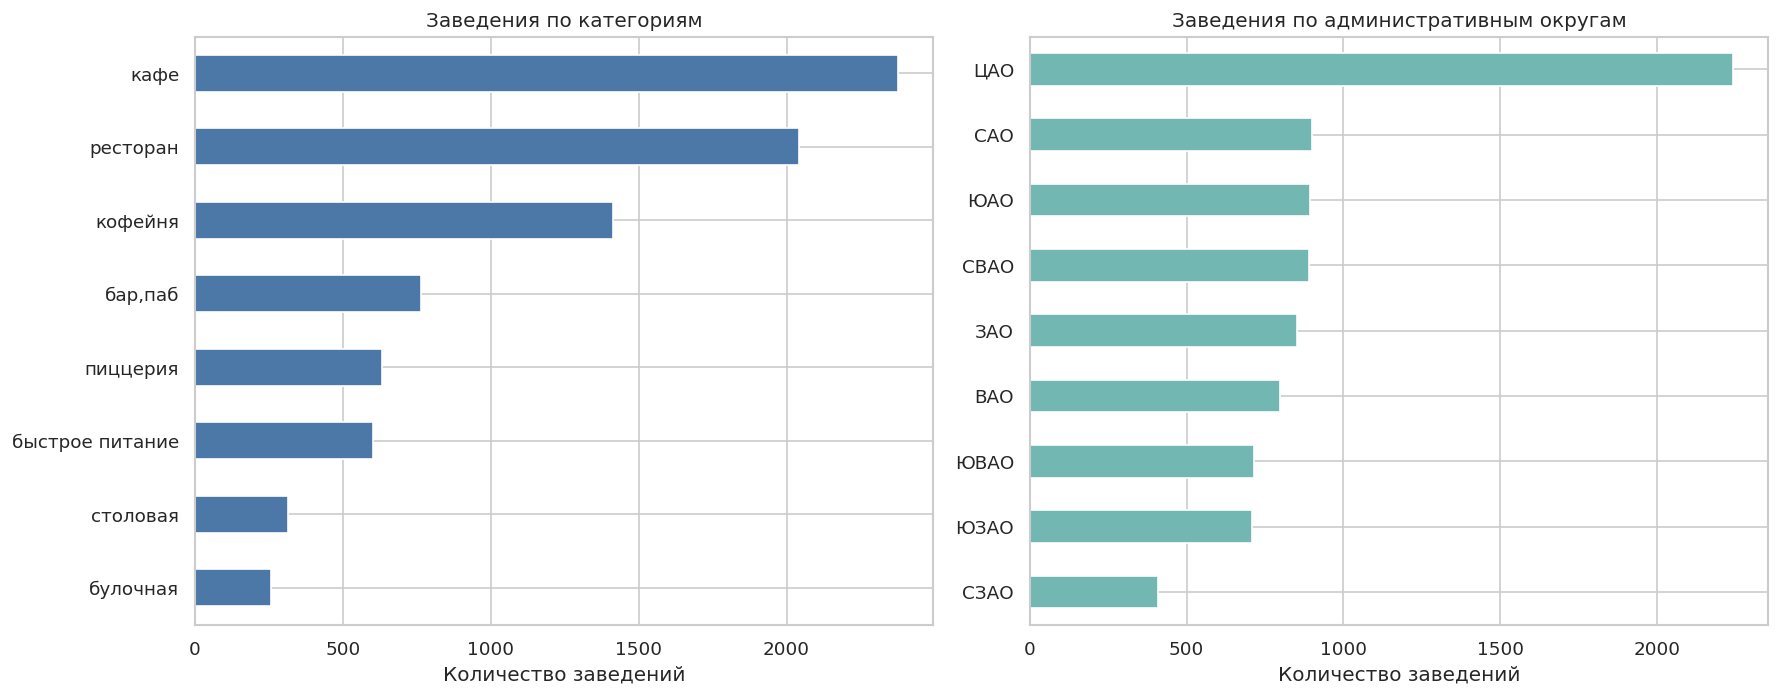

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

category_counts = df['category'].value_counts().sort_values()
category_counts.plot.barh(ax=axes[0], color='#4C78A8')
axes[0].set_title('Заведения по категориям')
axes[0].set_xlabel('Количество заведений')
axes[0].set_ylabel('')

district_counts = df['district'].value_counts().sort_values()
district_counts.plot.barh(ax=axes[1], color='#72B7B2')
axes[1].set_title('Заведения по административным округам')
axes[1].set_xlabel('Количество заведений')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

cao_categories = df.loc[df['district'].eq('ЦАО'), 'category'].value_counts()
print(f'Наиболее распространённая категория: {category_counts.idxmax()} — {category_counts.max():,}')
print(f'Заведений в ЦАО: {district_counts["ЦАО"]:,}')
print(f'Лидер ЦАО: {cao_categories.idxmax()} — {cao_categories.max():,}')

Кафе — крупнейшая категория: 2 377 объектов, или около 28% рынка. ЦАО лидирует по числу заведений (2 242), а внутри него наиболее представлены рестораны — 670 объектов.

## 3. Сетевые и независимые заведения

           count  share_pct
chain                      
Несетевые   5200       61.9
Сетевые     3205       38.1


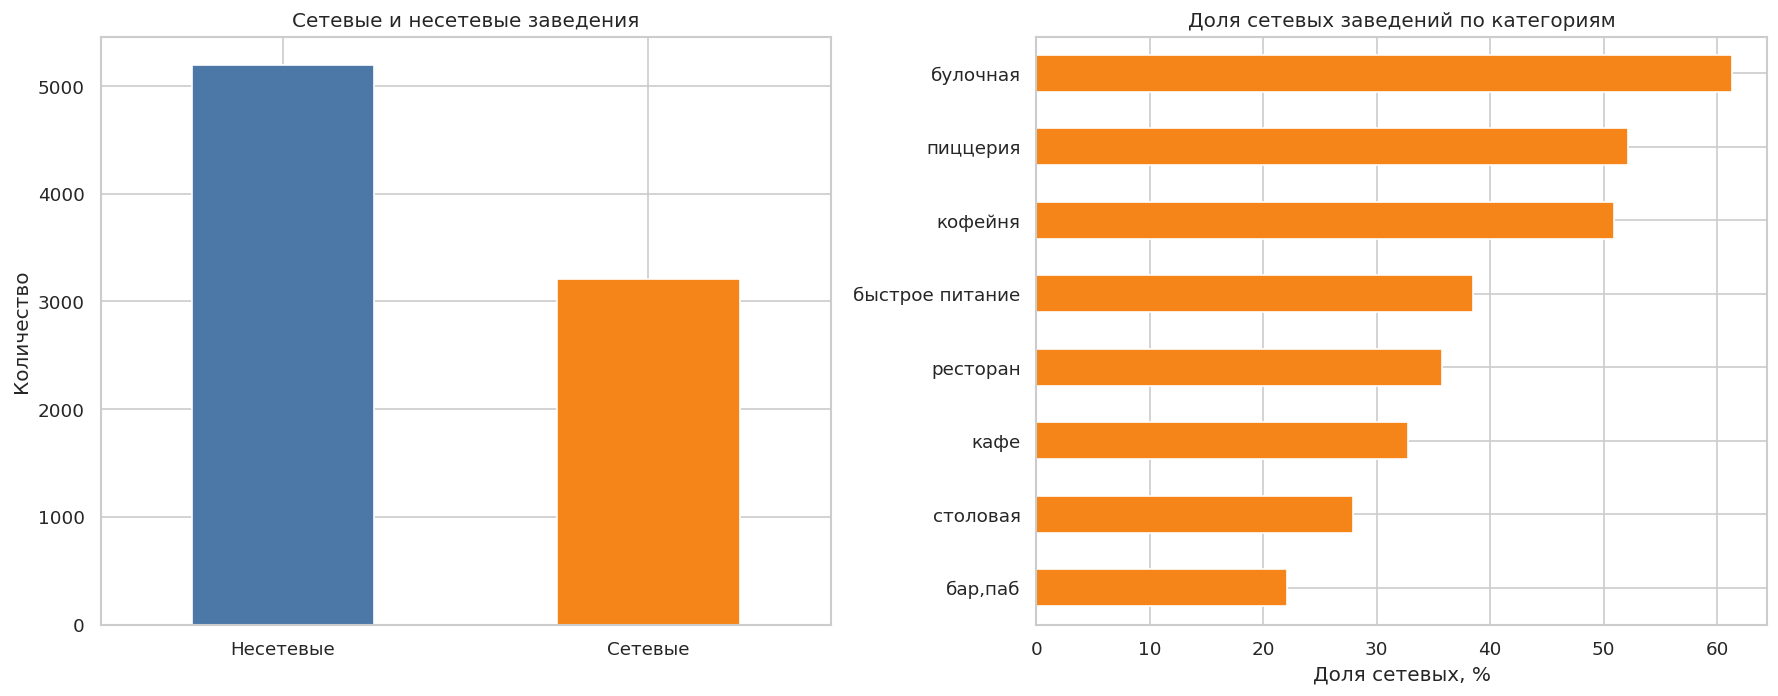

In [4]:
chain_counts = df['chain'].map({0: 'Несетевые', 1: 'Сетевые'}).value_counts()
chain_share = df.groupby('category')['chain'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
chain_counts.plot.bar(ax=axes[0], color=['#4C78A8', '#F58518'])
axes[0].set_title('Сетевые и несетевые заведения')
axes[0].set_xlabel('')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=0)

(chain_share * 100).sort_values().plot.barh(ax=axes[1], color='#F58518')
axes[1].set_title('Доля сетевых заведений по категориям')
axes[1].set_xlabel('Доля сетевых, %')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
display(pd.DataFrame({'count': chain_counts, 'share_pct': (chain_counts / len(df) * 100).round(1)}))

Несетевые объекты преобладают: 5 200 заведений против 3 205 сетевых. Самая высокая доля сетей наблюдается среди булочных (61%), пиццерий (52%) и кофеен (51%); самая низкая — среди баров и пабов (22%).

## 4. Посадочные места

                 count  median   mean
category                             
булочная           148    50.0   89.4
пиццерия           427    55.0   94.5
кафе              1218    60.0   97.5
быстрое питание    349    65.0   98.9
столовая           164    75.5   99.8
кофейня            751    80.0  111.2
бар,паб            468    82.5  124.5
ресторан          1270    86.0  121.9


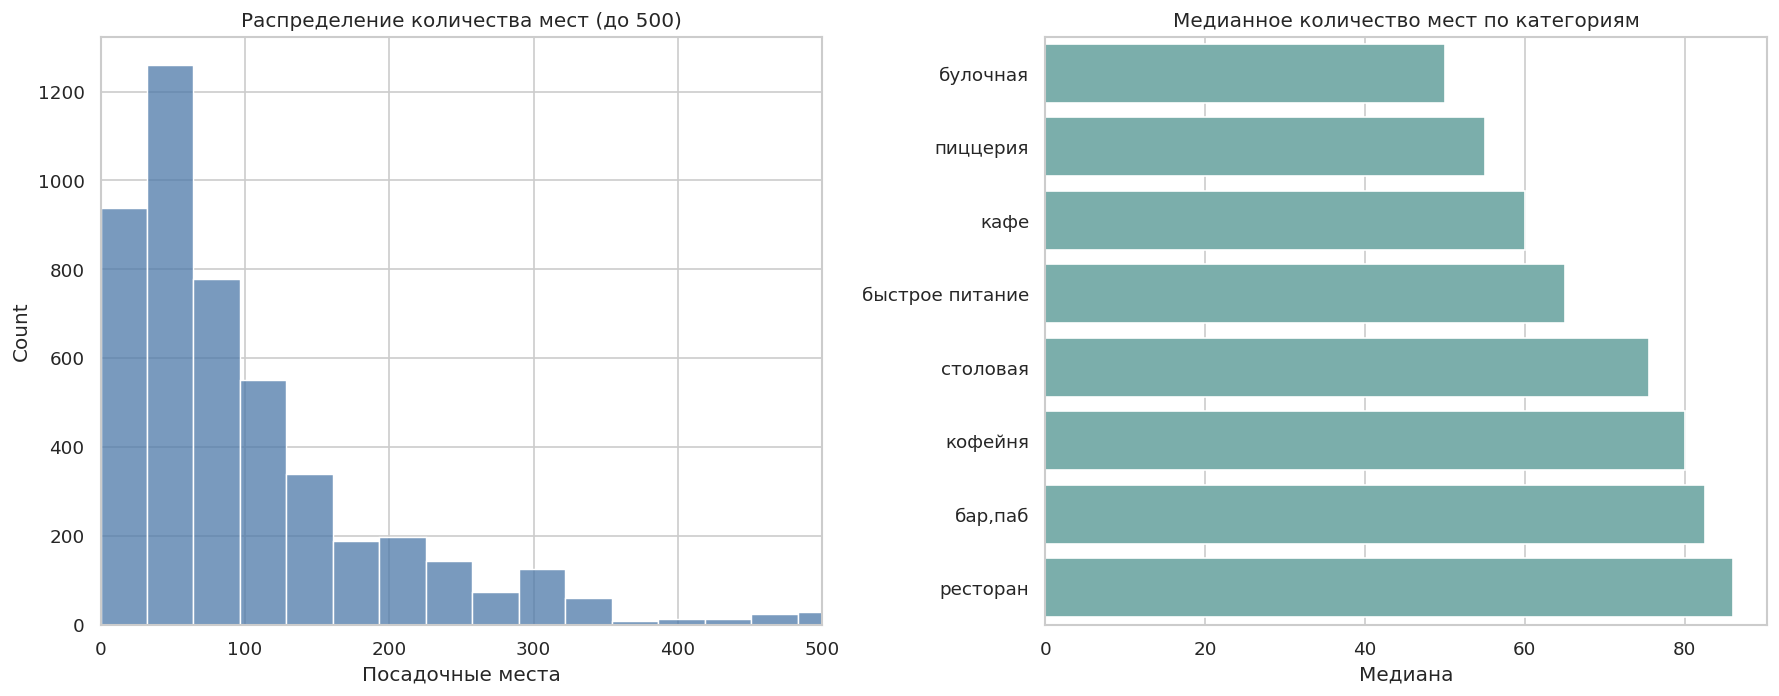

In [5]:
seats_summary = df.groupby('category')['seats'].agg(['count', 'median', 'mean']).sort_values('median')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(df['seats'].dropna(), bins=40, ax=axes[0], color='#4C78A8')
axes[0].set_xlim(0, 500)
axes[0].set_title('Распределение количества мест (до 500)')
axes[0].set_xlabel('Посадочные места')

sns.barplot(data=seats_summary.reset_index(), x='median', y='category', ax=axes[1], color='#72B7B2')
axes[1].set_title('Медианное количество мест по категориям')
axes[1].set_xlabel('Медиана')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
display(seats_summary.round(1))

Распределение имеет длинный правый хвост и значения до 1 288 мест, которые могут относиться к общим зонам фуд-кортов. Поэтому для типичного размера используется медиана: от 50 мест у булочных до 86 у ресторанов. Данные о местах отсутствуют примерно у 43% объектов, что ограничивает точность сравнения.

## 5. Рейтинги и факторы связи

category
бар,паб            4.39
пиццерия           4.30
ресторан           4.29
кофейня            4.28
булочная           4.27
столовая           4.21
кафе               4.12
быстрое питание    4.05
Name: mean_rating, dtype: float64


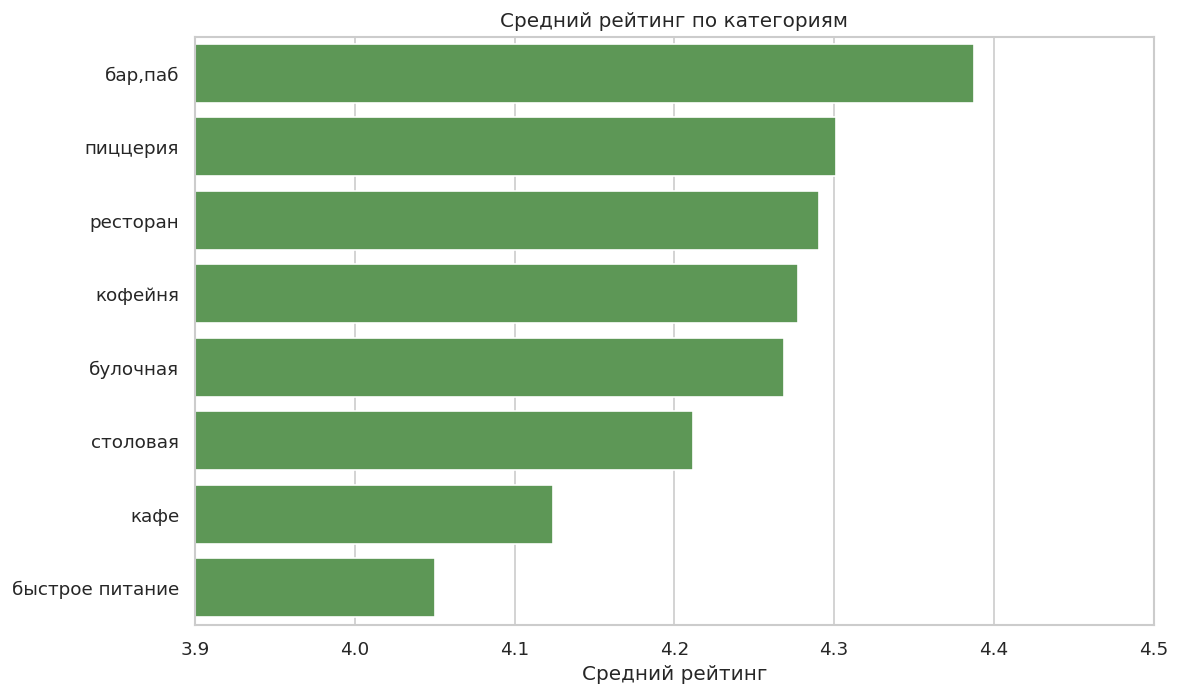

In [6]:
rating_by_category = df.groupby('category')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=rating_by_category.values, y=rating_by_category.index, color='#54A24B')
plt.xlim(3.9, 4.5)
plt.title('Средний рейтинг по категориям')
plt.xlabel('Средний рейтинг')
plt.ylabel('')
plt.tight_layout()
plt.show()
display(rating_by_category.round(2).rename('mean_rating'))

Ценовая категория         0.212
Категория заведения       0.207
Административный округ    0.202
Круглосуточная работа     0.103
Количество мест           0.021
Сетевой статус            0.015
Name: association, dtype: float64


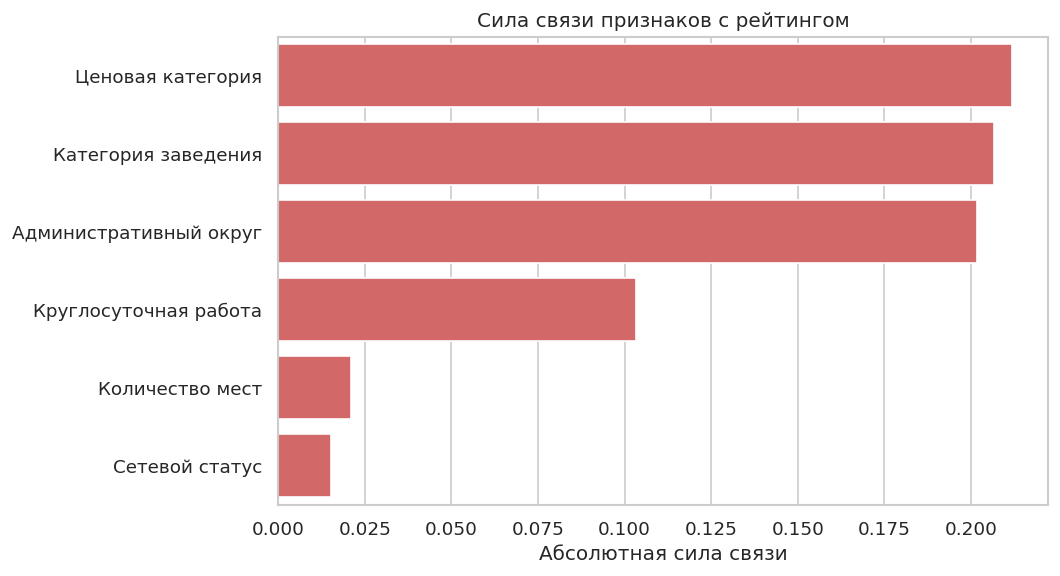

In [7]:
def correlation_ratio(categories, values):
    data = pd.DataFrame({'category': categories, 'value': values}).dropna()
    if data.empty:
        return np.nan
    grand_mean = data['value'].mean()
    numerator = sum(len(group) * (group['value'].mean() - grand_mean) ** 2
                    for _, group in data.groupby('category'))
    denominator = ((data['value'] - grand_mean) ** 2).sum()
    return np.sqrt(numerator / denominator) if denominator else 0.0

associations = {
    'Ценовая категория': correlation_ratio(df['price'], df['rating']),
    'Категория заведения': correlation_ratio(df['category'], df['rating']),
    'Административный округ': correlation_ratio(df['district'], df['rating']),
    'Количество мест': abs(df[['rating', 'seats']].corr().iloc[0, 1]),
    'Сетевой статус': abs(df[['rating', 'chain']].corr().iloc[0, 1]),
    'Круглосуточная работа': abs(df.assign(is_24_7_num=df['is_24_7'].astype(int))
                                  [['rating', 'is_24_7_num']].corr().iloc[0, 1]),
}
association_df = pd.Series(associations, name='association').sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=association_df.values, y=association_df.index, color='#E45756')
plt.title('Сила связи признаков с рейтингом')
plt.xlabel('Абсолютная сила связи')
plt.ylabel('')
plt.tight_layout()
plt.show()
display(association_df.round(3))

Средние рейтинги категорий близки: примерно от 4,05 у быстрого питания до 4,39 у баров и пабов. Среди проверенных признаков наиболее заметна связь рейтинга с ценовой категорией, однако она умеренная и не доказывает причинного влияния цены на оценку.

## 6. Популярные сети

                                   name  places  mean_rating  category
0                           ШОКОЛАДНИЦА     120         4.18   кофейня
1                        ДОМИНО'С ПИЦЦА      76         4.17  пиццерия
2                            ДОДО ПИЦЦА      74         4.29  пиццерия
3                      ONE PRICE COFFEE      71         4.06   кофейня
4                          ЯНДЕКС ЛАВКА      69         3.87  ресторан
5                                 COFIX      65         4.08   кофейня
6                                 PRIME      50         4.12  ресторан
7                            ХИНКАЛЬНАЯ      44         4.32      кафе
8                              КОФЕПОРТ      42         4.15   кофейня
9   КУЛИНАРНАЯ ЛАВКА БРАТЬЕВ КАРАВАЕВЫХ      39         4.39      кафе
10                              ТЕРЕМОК      38         4.12  ресторан
11                              ЧАЙХАНА      37         3.92      кафе
12                              БУХАНКА      32         4.40  булочная
13    

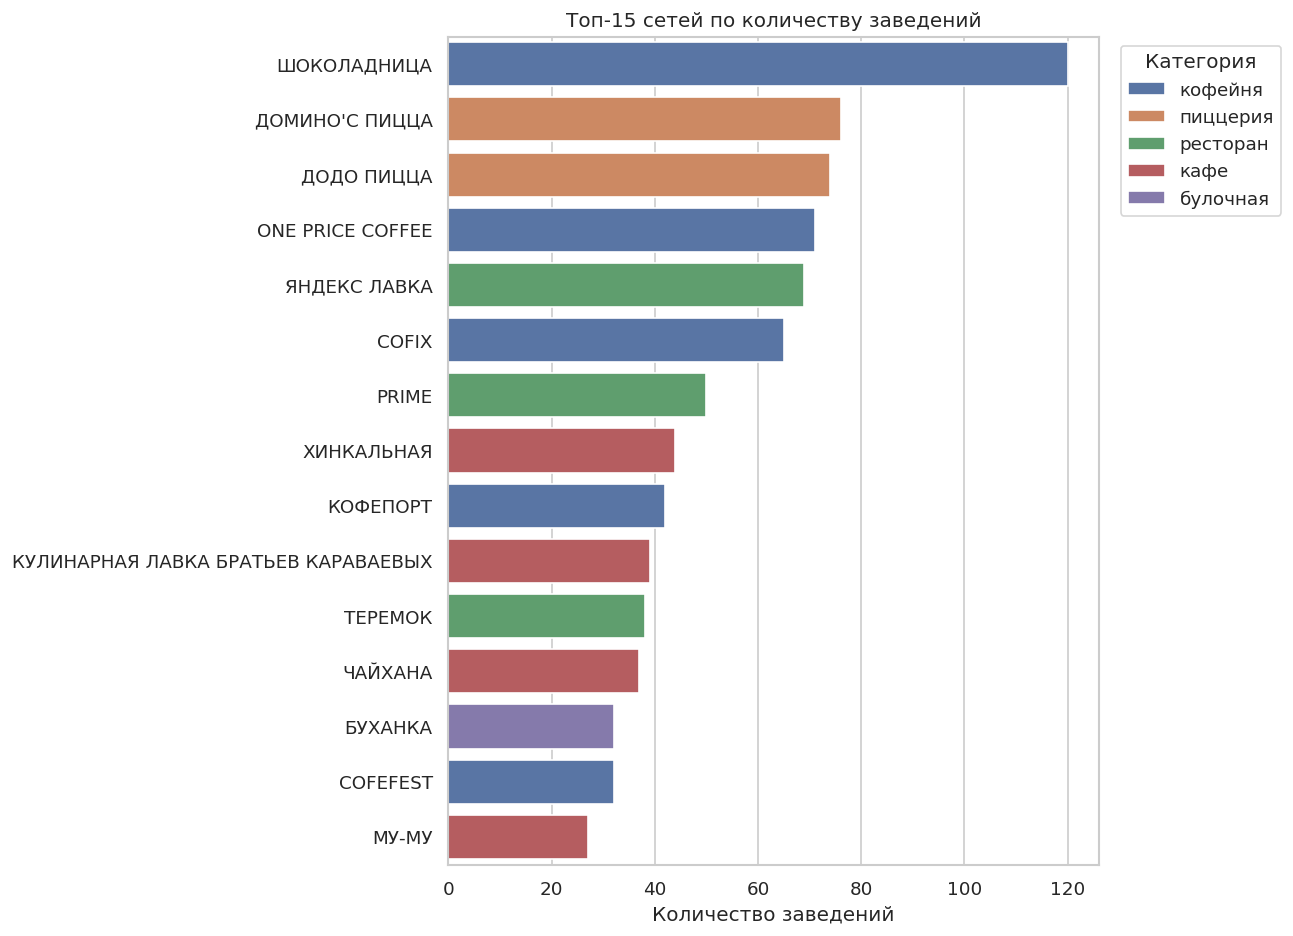

In [8]:
top_networks = (
    df.loc[df['chain'].eq(1)]
      .groupby('name')
      .agg(
          places=('id', 'size'),
          mean_rating=('rating', 'mean'),
          category=('category', lambda x: x.mode().iat[0])
      )
      .sort_values('places', ascending=False)
      .head(15)
      .reset_index()
)

plt.figure(figsize=(11, 8))
sns.barplot(data=top_networks, x='places', y='name', hue='category', dodge=False)
plt.title('Топ-15 сетей по количеству заведений')
plt.xlabel('Количество заведений')
plt.ylabel('')
plt.legend(title='Категория', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
display(top_networks.round({'mean_rating': 2}))

Крупнейшая сеть в выборке — «Шоколадница» со 120 заведениями и средним рейтингом 4,18. Высокий рейтинг внутри топ-15 сам по себе не означает коммерческого преимущества: данные не содержат выручку, трафик и операционные расходы.

## 7. Средний чек по округам

          count    mean  median
district                       
ЦАО        1060  1191.0  1000.0
ЗАО         306  1053.0  1000.0
САО         322   928.0   650.0
ЮАО         314   834.0   500.0
СЗАО        157   822.0   700.0
ВАО         260   821.0   575.0
ЮЗАО        235   793.0   600.0
СВАО        301   717.0   500.0
ЮВАО        194   654.0   450.0


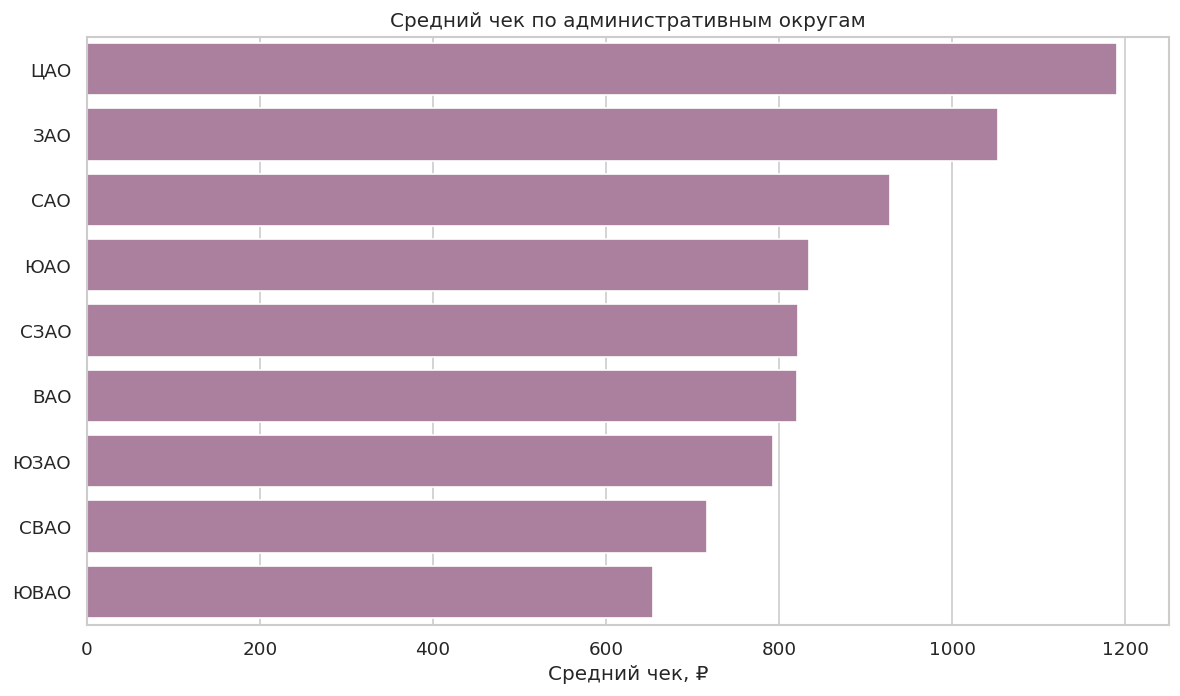

In [9]:
bill_by_district = (
    df.groupby('district')['middle_avg_bill']
      .agg(['count', 'mean', 'median'])
      .sort_values('mean', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=bill_by_district.reset_index(), x='mean', y='district', color='#B279A2')
plt.title('Средний чек по административным округам')
plt.xlabel('Средний чек, ₽')
plt.ylabel('')
plt.tight_layout()
plt.show()
display(bill_by_district.round(0))

Средний чек максимален в ЦАО — около 1 191 ₽, минимален в ЮВАО — около 654 ₽. Это согласуется с более высоким ценовым уровнем центра, но вывод ограничен пропусками: `middle_avg_bill` заполнен только примерно для 37% заведений.

## Итоговые выводы и рекомендации

Анализ охватывает 8 405 заведений Москвы после очистки и объединения данных.

### Основные выводы

- Кафе формируют крупнейшую категорию — около 28% объектов, поэтому конкуренция в этом формате особенно высока.
- В ЦАО сосредоточено 2 242 заведения; лидирующая категория округа — рестораны.
- Независимых заведений больше сетевых: 5 200 против 3 205.
- Сетевой формат особенно распространён среди булочных, пиццерий и кофеен.
- Средние рейтинги категорий различаются слабо; рейтинг нельзя объяснить одним из рассмотренных признаков.
- Средний чек снижается от ЦАО к части периферийных округов: примерно от 1 191 ₽ в ЦАО до 654 ₽ в ЮВАО.

### Рекомендации инвесторам

1. Не выбирать формат только по числу конкурентов. Перед запуском дополнительно оценить пешеходный трафик, аренду, офисную и жилую аудиторию конкретной локации.
2. Для премиального позиционирования рассматривать ЦАО, одновременно учитывая высокую конкуренцию и вероятно более дорогую аренду.
3. Для более доступной концепции изучить ЮВАО и СВАО, где средний чек ниже; окончательное решение принимать после локального анализа спроса.
4. В качестве стартового ориентира для небольшого объекта использовать 50–90 посадочных мест, но корректировать вместимость под формат и локацию.
5. Отдельно протестировать менее насыщенные форматы, например бар или паб, не считая меньшую представленность автоматическим доказательством высокого спроса.

Данные отражают состояние рынка летом 2022 года и не содержат выручку, посещаемость, аренду и финансовые результаты. Поэтому рекомендации следует рассматривать как основу для выбора гипотез, а не готовое инвестиционное решение.
